# 전국 주요관광지점 입장객 데이터 병합 파이프라인

- **소스**: 문화체육관광부 관광지식정보시스템 (know.tour.go.kr)
- **입력**: 시도별 xls 파일 17개
- **출력**: `visitor_clean.csv` — tidy 형태 (관광지 × 연월 × 방문객수)
- **유효 기간**: 2011 ~ 2024년 (데이터 안정적인 구간)
- **결측 처리**: 결측률 90% 이상 관광지 제거 → 나머지 선형보간

## 0. 환경 설정

In [1]:
# 필요 라이브러리 임포트
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ─── 경로 설정 (여기만 수정) ───────────────────────────────
DATA_DIR = Path("./data/visitor")   # xls 파일들이 있는 폴더
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 유효 연도 범위
YEAR_START = 2011
YEAR_END   = 2024

# 결측률 기준 — 이 이상이면 관광지 자체를 제거
NULL_DROP_THRESHOLD = 0.90
# ────────────────────────────────────────────────────────────

print(f"데이터 폴더: {DATA_DIR.resolve()}")
xls_files = list(DATA_DIR.glob("*.xls")) + list(DATA_DIR.glob("*.xlsx"))
print(f"발견된 파일 수: {len(xls_files)}개")
for f in sorted(xls_files):
    print(f"  {f.name}")

데이터 폴더: C:\Users\user\OneDrive\Desktop\contest\tour-recommend\data\visitor
발견된 파일 수: 17개
  강원특별자치도.xls
  경기도.xls
  경상남도.xls
  경상북도.xls
  광주광역시.xls
  대구광역시.xls
  대전광역시.xls
  부산광역시.xls
  서울특별시.xls
  세종특별자치시.xls
  울산광역시.xls
  인천광역시.xls
  전라남도.xls
  전북특별자치도.xls
  제주특별자치도.xls
  충청남도.xls
  충청북도.xls


## 1. 단일 파일 파싱 함수

In [2]:
def parse_visitor_xls(filepath: Path) -> pd.DataFrame:
    """
    관광지식정보시스템 xls 파일 → tidy DataFrame 변환
    
    반환 컬럼:
        sido, sigungu, site, year, month, ym, visitors_total,
        visitors_domestic, visitors_foreign
    """
    # xls는 LibreOffice로 변환 필요, xlsx는 바로 읽기
    suffix = filepath.suffix.lower()
    if suffix == '.xls':
        try:
            df_raw = pd.read_excel(filepath, engine='xlrd', header=None)
        except Exception:
            # xlrd 실패 시 openpyxl fallback (확장자가 .xls여도 xlsx 포맷인 경우)
            df_raw = pd.read_excel(filepath, engine='openpyxl', header=None)
    else:
        df_raw = pd.read_excel(filepath, engine='openpyxl', header=None)

    # 월 컬럼 인덱스 추출 (row 1에 '2004년 07월' 형식)
    month_cols = {}
    for col_idx in range(5, df_raw.shape[1]):
        val = str(df_raw.iloc[1, col_idx])
        if '년' in val and '월' in val:
            month_cols[col_idx] = val

    if not month_cols:
        print(f"  [WARN] 월 컬럼 없음: {filepath.name}")
        return pd.DataFrame()

    # 내/외국인 구분별 행 추출
    df_total    = df_raw[df_raw[3] == '합계'].copy()
    df_domestic = df_raw[df_raw[3] == '내국인'].copy()
    df_foreign  = df_raw[df_raw[3] == '외국인'].copy()

    def rows_to_tidy(df_sub, val_col_name):
        records = []
        for _, row in df_sub.iterrows():
            sido    = str(row[0]).strip()
            sigungu = str(row[1]).strip()
            site    = str(row[2]).strip()
            for col_idx, month_str in month_cols.items():
                year  = int(month_str[:4])
                month = int(month_str[6:8])
                raw   = row[col_idx]
                val   = (
                    float(raw)
                    if pd.notna(raw) and str(raw).strip() not in ('', 'nan')
                    else np.nan
                )
                records.append({
                    'sido': sido, 'sigungu': sigungu, 'site': site,
                    'year': year, 'month': month,
                    'ym': f"{year:04d}-{month:02d}",
                    val_col_name: val
                })
        return pd.DataFrame(records)

    df_t = rows_to_tidy(df_total,    'visitors_total')
    df_d = rows_to_tidy(df_domestic, 'visitors_domestic')
    df_f = rows_to_tidy(df_foreign,  'visitors_foreign')

    # 병합 (site+ym 기준)
    key = ['sido', 'sigungu', 'site', 'year', 'month', 'ym']
    if df_d.empty or df_f.empty:
        # 내/외국인 구분 없는 파일 (합계만 존재)
        df_merged = df_t
        df_merged['visitors_domestic'] = np.nan
        df_merged['visitors_foreign']  = np.nan
    else:
        df_merged = df_t.merge(df_d[key + ['visitors_domestic']], on=key, how='left')
        df_merged = df_merged.merge(df_f[key + ['visitors_foreign']],  on=key, how='left')

    return df_merged

## 2. 전국 파일 병합

In [3]:
all_dfs = []

for fpath in sorted(xls_files):
    print(f"처리 중: {fpath.name} ...", end=' ')
    try:
        df = parse_visitor_xls(fpath)
        if df.empty:
            print("SKIP (빈 데이터)")
            continue
        all_dfs.append(df)
        print(f"OK ({len(df):,}행, 관광지 {df['site'].nunique()}개)")
    except Exception as e:
        print(f"ERROR: {e}")

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"\n병합 완료: {len(df_all):,}행, {df_all['site'].nunique()}개 관광지, {df_all['sido'].nunique()}개 시도")

처리 중: 강원특별자치도.xls ... OK (103,944행, 관광지 566개)
처리 중: 경기도.xls ... OK (111,081행, 관광지 594개)
처리 중: 경상남도.xls ... OK (87,840행, 관광지 480개)
처리 중: 경상북도.xls ... OK (118,584행, 관광지 647개)
처리 중: 광주광역시.xls ... OK (14,823행, 관광지 81개)
처리 중: 대구광역시.xls ... OK (24,339행, 관광지 133개)
처리 중: 대전광역시.xls ... OK (9,150행, 관광지 50개)
처리 중: 부산광역시.xls ... OK (7,320행, 관광지 40개)
처리 중: 서울특별시.xls ... OK (4,209행, 관광지 23개)
처리 중: 세종특별자치시.xls ... OK (3,477행, 관광지 19개)
처리 중: 울산광역시.xls ... OK (12,261행, 관광지 67개)
처리 중: 인천광역시.xls ... OK (17,934행, 관광지 98개)
처리 중: 전라남도.xls ... OK (123,525행, 관광지 672개)
처리 중: 전북특별자치도.xls ... OK (63,501행, 관광지 347개)
처리 중: 제주특별자치도.xls ... OK (8,967행, 관광지 49개)
처리 중: 충청남도.xls ... OK (72,285행, 관광지 384개)
처리 중: 충청북도.xls ... OK (85,095행, 관광지 458개)

병합 완료: 868,335행, 4670개 관광지, 17개 시도


## 3. 전처리

In [4]:
# ── 3-1. 유효 연도 필터링 ──────────────────────────────────
df = df_all[df_all['year'].between(YEAR_START, YEAR_END)].copy()
print(f"연도 필터 ({YEAR_START}~{YEAR_END}): {len(df):,}행")

# ── 3-2. 결측률 진단 ──────────────────────────────────────
site_null = (
    df.groupby(['sido', 'site'])['visitors_total']
    .apply(lambda x: x.isna().mean())
    .reset_index()
    .rename(columns={'visitors_total': 'null_rate'})
    .sort_values('null_rate', ascending=False)
)

print(f"\n결측률 분포:")
bins = [0, 0.1, 0.3, 0.5, 0.9, 1.01]
labels = ['0~10%', '10~30%', '30~50%', '50~90%', '90~100%']
site_null['null_bin'] = pd.cut(site_null['null_rate'], bins=bins, labels=labels, right=False)
print(site_null['null_bin'].value_counts().sort_index())

# 제거 대상
drop_sites = site_null[site_null['null_rate'] >= NULL_DROP_THRESHOLD][['sido', 'site']]
print(f"\n제거 관광지 ({NULL_DROP_THRESHOLD*100:.0f}% 이상 결측): {len(drop_sites)}개")
if len(drop_sites) > 0:
    print(drop_sites.to_string(index=False))

연도 필터 (2011~2024): 797,160행

결측률 분포:
null_bin
0~10%       719
10~30%      603
30~50%      492
50~90%     2392
90~100%     502
Name: count, dtype: int64

제거 관광지 (90% 이상 결측): 502개
   sido                   site
    경기도                 VR 체험관
    경기도             XR버스 1795행
    경기도            가평 베고니아 새정원
   충청북도           벨포레리조트 마운틴카트
    경기도                  가평크루즈
    경기도          국립극장 무대예술지원센터
    경기도             김포시독립운동기념관
   충청북도         삼기조아유 농촌체험휴양마을
   충청북도             생거진천 자연휴양림
   충청북도               생거판화 미술관
   충청북도              세계 기독교박물관
   충청북도                 시골살이마을
   충청북도                시항골체험마을
강원특별자치도            경포비치리조트(효산)
강원특별자치도            경포산장휴양콘도미니엄
   충청북도               영동금강모치마을
    경기도                  뮤지엄헤이
    경기도              미술관 옆 캠핑장
    경기도               샴발라컨트리클럽
   충청북도                  별빛화목원
   충청북도           벨포레리조트 모토아레나
   충청북도            벨포레리조트 미니골프
   충청북도         벨포레리조트 미디어아트센터
   충청북도          벨포레리조트 벨포레 목장
   충청북도         벨포레리조트 사계절 썰매장
   충청북도         

In [5]:
# ── 3-3. 결측 관광지 제거 ──────────────────────────────────
drop_key = set(zip(drop_sites['sido'], drop_sites['site']))
df = df[~df.apply(lambda r: (r['sido'], r['site']) in drop_key, axis=1)].copy()
print(f"제거 후: {len(df):,}행, {df['site'].nunique()}개 관광지")

# ── 3-4. 선형 보간 (관광지 × 컬럼별) ──────────────────────
df = df.sort_values(['sido', 'site', 'ym'])

for col in ['visitors_total', 'visitors_domestic', 'visitors_foreign']:
    before = df[col].isna().sum()
    df[col] = df.groupby(['sido', 'site'])[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    after = df[col].isna().sum()
    print(f"{col}: 결측 {before}개 → 보간 후 {after}개")

# ── 3-5. 외국인 비율 컬럼 추가 ────────────────────────────
df['foreign_ratio'] = (
    df['visitors_foreign'] / df['visitors_total']
).round(4)

print(f"\n최종 결측 확인:")
print(df[['visitors_total', 'visitors_domestic', 'visitors_foreign']].isna().sum())

제거 후: 710,640행, 4170개 관광지
visitors_total: 결측 364640개 → 보간 후 0개
visitors_domestic: 결측 364681개 → 보간 후 0개
visitors_foreign: 결측 524445개 → 보간 후 374808개

최종 결측 확인:
visitors_total            0
visitors_domestic         0
visitors_foreign     374808
dtype: int64


## 4. 결과 저장 및 요약

In [6]:
# 저장
out_path = OUTPUT_DIR / 'visitor_clean.csv'
df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"✅ 저장 완료: {out_path}")
print(f"   행 수     : {len(df):,}")
print(f"   관광지 수  : {df['site'].nunique()}개")
print(f"   시도 수    : {df['sido'].nunique()}개")
print(f"   기간       : {df['ym'].min()} ~ {df['ym'].max()}")
print(f"   컬럼       : {list(df.columns)}")

✅ 저장 완료: output\visitor_clean.csv
   행 수     : 710,640
   관광지 수  : 4170개
   시도 수    : 17개
   기간       : 2011-01 ~ 2024-12
   컬럼       : ['sido', 'sigungu', 'site', 'year', 'month', 'ym', 'visitors_total', 'visitors_domestic', 'visitors_foreign', 'foreign_ratio']


In [7]:
# 시도별 관광지 수 요약
summary = (
    df.groupby('sido')
    .agg(
        site_count=('site', 'nunique'),
        total_visitors=('visitors_total', 'sum'),
        avg_monthly=('visitors_total', 'mean')
    )
    .sort_values('total_visitors', ascending=False)
    .reset_index()
)
summary['total_visitors'] = summary['total_visitors'].map('{:,.0f}'.format)
summary['avg_monthly']    = summary['avg_monthly'].map('{:,.0f}'.format)
print("\n=== 시도별 요약 ===")
print(summary.to_string(index=False))


=== 시도별 요약 ===
   sido  site_count total_visitors avg_monthly
   전라남도         628  1,544,630,576      14,571
   경상북도         597  1,339,763,283      13,336
    경기도         537  1,254,334,962      13,575
   충청남도         365  1,184,979,992      19,219
강원특별자치도         458  1,132,112,510      14,681
   경상남도         411    937,753,622      13,581
전북특별자치도         302    902,687,230      17,792
   충청북도         398    687,068,068      10,173
  대구광역시         122    678,514,055      33,105
  부산광역시          38    449,273,912      70,375
  인천광역시          92    446,878,385      28,913
  서울특별시          23    373,488,656      96,659
  광주광역시          71    286,564,730      24,025
  대전광역시          41    258,608,227      37,545
제주특별자치도          48    256,463,521      31,804
  울산광역시          61    231,651,559      22,605
세종특별자치시          14     15,422,740       6,557


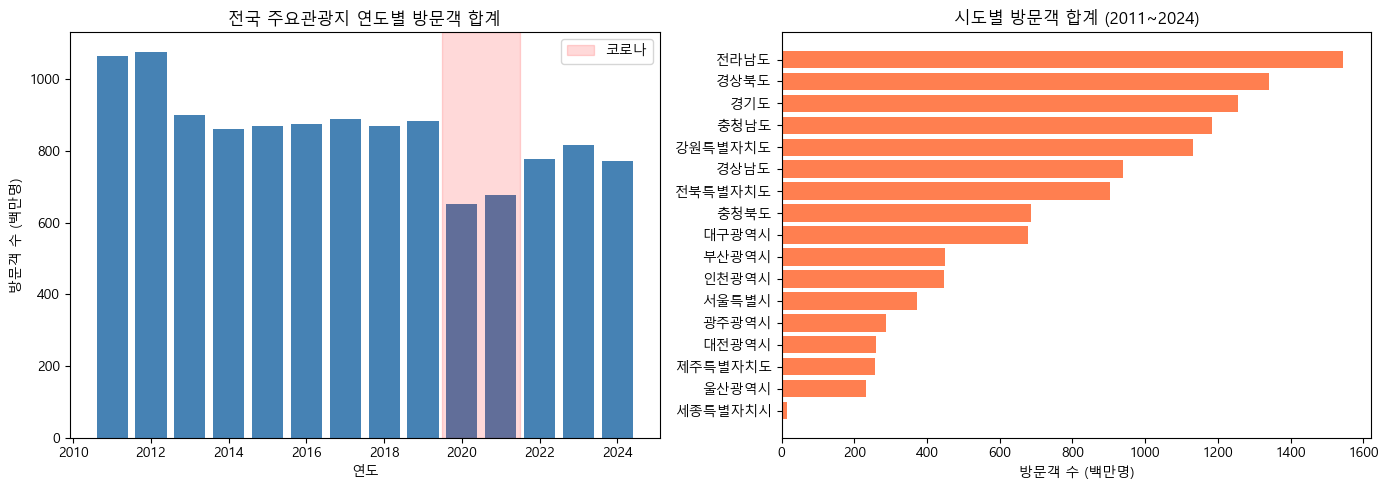

시각화 저장 완료


In [8]:
# 결측 패턴 시각화
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.rcParams['font.family'] = 'AppleGothic'   # Mac
matplotlib.rcParams['font.family'] = 'Malgun Gothic' # Windows
matplotlib.rcParams['axes.unicode_minus'] = False

# 연도별 평균 방문객 (전국 합계)
yearly = df.groupby('year')['visitors_total'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연도별 전국 방문객 합계
axes[0].bar(yearly['year'], yearly['visitors_total'] / 1e6, color='steelblue')
axes[0].set_title('전국 주요관광지 연도별 방문객 합계')
axes[0].set_ylabel('방문객 수 (백만명)')
axes[0].set_xlabel('연도')
axes[0].axvspan(2019.5, 2021.5, alpha=0.15, color='red', label='코로나')
axes[0].legend()

# 시도별 방문객 비중
sido_sum = df.groupby('sido')['visitors_total'].sum().sort_values(ascending=True)
axes[1].barh(sido_sum.index, sido_sum.values / 1e6, color='coral')
axes[1].set_title('시도별 방문객 합계 (2011~2024)')
axes[1].set_xlabel('방문객 수 (백만명)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'visitor_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("시각화 저장 완료")